# Day 1 — 04. The neuron, nonlinearity, and learning

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Estimated duration:** approximately 30 minutes.

Neurons, activation functions, losses, and the mathematics of learning.

Run the cells from top to bottom. This notebook is one independent part of the Day 1 workshop.

In [1]:
# --- Setup --- 

# Restart the kernel before running this cell if Matplotlib was already loaded.
import ipympl
# Enable interactive rotation and zooming for Matplotlib figures in VS Code.
get_ipython().run_line_magic("matplotlib", "ipympl")

# Import the numerical and plotting libraries used throughout Day 1.
import numpy as np
import matplotlib.pyplot as plt

# Choose plotting defaults that keep axes and mathematical curves readable.
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})

## 4. The neuron, nonlinearity, and learning

Suggested time: 30 minutes.

We can now express the affine models from the previous sections as neurons. Adding an activation function changes the output behavior and allows us to formulate both regression and classification tasks within the same framework.

### 4.1 From a linear model to a neuron

A neuron is a parameterized function that receives an input vector $x\in\mathbb{R}^d$, computes a weighted sum, and optionally applies an activation function:

$$
z=w^Tx+b,\qquad a=\phi(z).
$$

The weights $w$ determine how strongly each input contributes, the bias $b$ shifts the response, $z$ is the preactivation, and $a$ is the neuron output. The parameters $w$ and $b$ are trainable; the input is not.

A linear-regression model is exactly a neuron with the identity activation $\phi(z)=z$. In that case, $a=w^Tx+b=\hat{y}$, so the neuron and the linear model have the same parameters and the same prediction equation. The distinction appears when $\phi$ is nonlinear: a sigmoid neuron can produce a probability, while several neurons can be combined into a layer and then into a deeper network.

This connection is useful: linear regression provides the simplest setting in which we can understand trainable weights, bias, loss, gradients, and parameter updates. Neural networks reuse the same ingredients, but compose many neurons and introduce nonlinear transformations.

### 4.2 Activation functions and nonlinearity

The activation function transforms the preactivation $z$ into the neuron output $a=\phi(z)$. It determines the range and interpretation of the output, and—when it is nonlinear—it allows a network to represent relationships that cannot be expressed by a single affine model.

Some useful examples are:

| Activation | Expression | Typical use |
| --- | --- | --- |
| Identity | $\phi(z)=z$ | Regression output; preserves the real-valued prediction. |
| Sigmoid | $\sigma(z)=1/(1+e^{-z})$ | Binary probability output in $(0,1)$. |
| ReLU | $\max(0,z)$ | Hidden layers; simple nonlinear transformation. |
| Tanh | $\tanh(z)$ | Hidden layers when a centered output in $(-1,1)$ is useful. |

The identity activation leaves the neuron equivalent to linear regression. A nonlinear activation changes the model's geometry: a single neuron can create a nonlinear scalar response, and stacking nonlinear layers enables the network to build increasingly complex representations. Without nonlinear activations, a stack of affine layers is still just one affine transformation.

### 4.3 Regression or classification?

The task determines what the neuron should output. In regression, the target is a continuous quantity—such as biomass, soil moisture, or surface temperature—so the output layer commonly uses the identity activation. In binary classification, the target indicates one of two classes, so a sigmoid output is interpreted as a probability. For multiclass classification, several output neurons are commonly combined with a softmax function to produce a probability distribution over classes.

This distinction is about the meaning of the output, not about a completely different training principle. In all cases, the model computes an output, compares it with the target using a suitable loss, and updates its trainable parameters.

For remote sensing, regression may estimate a continuous biophysical variable from spectral features, while classification may assign a pixel or patch to a land-cover class. The same input representation can therefore support different tasks, provided that the output layer, targets, and loss are chosen consistently.

The visualization below compares the identity and sigmoid functions and previews several losses used for regression and binary classification. The next cell then uses dummy observations to connect these output choices with regression and classification results.

#### Visualization guide: regression and binary classification outputs

The first figure uses an identity output, so the model produces a continuous value for regression. The second uses a sigmoid output, so the model produces a probability that is converted into a binary class using the threshold $p=0.5$; the confusion matrix summarizes the resulting predictions.

Look at the difference between a continuous output and a probability output. You can change the regression noise, the dummy classification values in `z_cls` and `y_cls`, and the decision threshold used to create `predicted_class`.

**Open question:** How would changing the classification threshold alter the confusion matrix, and when might a threshold other than $0.5$ be preferable?

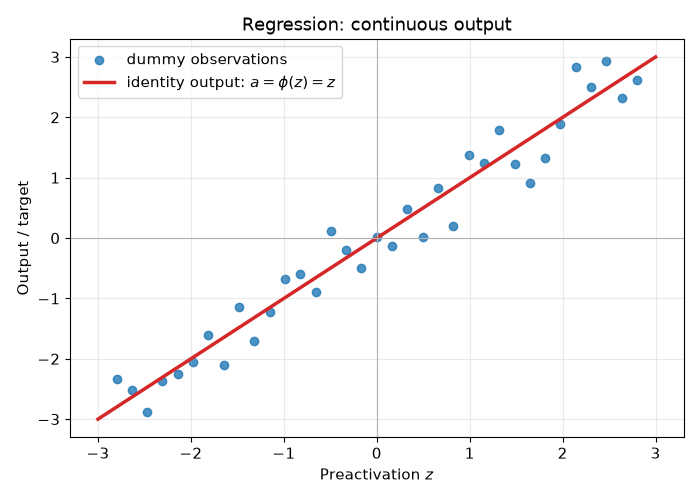

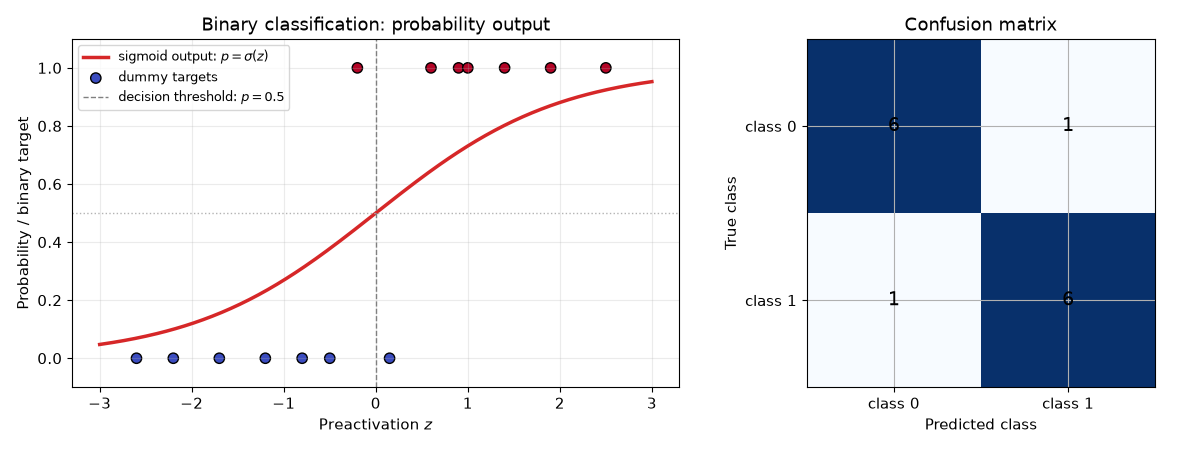

In [2]:
# Use the preactivation z as the horizontal coordinate so the output behavior is explicit.
z_range = np.linspace(-3, 3, 300)
rng = np.random.default_rng(24)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Regression uses the identity activation: a = phi(z) = z.
z_reg = np.linspace(-2.8, 2.8, 35)
y_reg = z_reg + rng.normal(0, 0.35, size=z_reg.size)
regression_output = z_range

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(z_reg, y_reg, color="tab:blue", alpha=0.8, label="dummy observations")
ax.plot(z_range, regression_output, color="tab:red", linewidth=2.5, label=r"identity output: $a=\phi(z)=z$")
ax.set_title("Regression: continuous output")
ax.set_xlabel("Preactivation $z$")
ax.set_ylabel("Output / target")
ax.axhline(0, color="0.7", linewidth=0.8)
ax.axvline(0, color="0.7", linewidth=0.8)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Binary classification uses a sigmoid probability and a threshold at p = 0.5.
z_cls = np.array([-2.6, -2.2, -1.7, -1.2, -0.8, -0.5, -0.2, 0.15, 0.6, 0.9, 1.0, 1.4, 1.9, 2.5])
y_cls = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])
probability = sigmoid(z_cls)
predicted_class = (probability >= 0.5).astype(int)

confusion = np.zeros((2, 2), dtype=int)
for true_class, predicted in zip(y_cls, predicted_class):
    confusion[true_class, predicted] += 1

fig, (ax_probability, ax_confusion) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.5, 1]})
ax_probability.plot(z_range, sigmoid(z_range), color="tab:red", linewidth=2.5, label=r"sigmoid output: $p=\sigma(z)$")
ax_probability.scatter(z_cls, y_cls, c=y_cls, cmap="coolwarm", vmin=0, vmax=1, edgecolor="black", s=55, label="dummy targets")
ax_probability.axvline(0, color="0.5", linestyle="--", linewidth=1, label="decision threshold: $p=0.5$")
ax_probability.axhline(0.5, color="0.7", linestyle=":", linewidth=1)
ax_probability.set_title("Binary classification: probability output")
ax_probability.set_xlabel("Preactivation $z$")
ax_probability.set_ylabel("Probability / binary target")
ax_probability.set_ylim(-0.1, 1.1)
ax_probability.legend(fontsize=9)
ax_probability.grid(alpha=0.25)

ax_confusion.imshow(confusion, cmap="Blues")
for true_class in range(2):
    for predicted in range(2):
        ax_confusion.text(predicted, true_class, confusion[true_class, predicted], ha="center", va="center", fontsize=14)
ax_confusion.set_title("Confusion matrix")
ax_confusion.set_xlabel("Predicted class")
ax_confusion.set_ylabel("True class")
ax_confusion.set_xticks([0, 1], ["class 0", "class 1"])
ax_confusion.set_yticks([0, 1], ["class 0", "class 1"])
fig.tight_layout()
plt.show()

### 4.4 Loss functions

A loss function measures how different the predictions are from the desired targets. It converts the training problem into a scalar objective that can be minimized. The choice of loss depends on the target and on the meaning we assign to the model output.

| Task | Output | Common loss | Main idea |
| --- | --- | --- | --- |
| Regression | real-valued $\hat{y}$ | Mean squared error (MSE) | Penalizes large errors strongly. |
| Regression | real-valued $\hat{y}$ | Mean absolute error (MAE) | More robust to outliers than MSE. |
| Regression | real-valued $\hat{y}$ | Huber loss | Quadratic near zero and linear for large errors. |
| Binary classification | probability $p\in(0,1)$ | Binary cross-entropy | Penalizes confident, incorrect probabilities strongly. |
| Multiclass classification | probability vector $p$ | Categorical cross-entropy | Compares the predicted and target class distributions. |

For regression, the mean squared error is

$$
\mathcal{L}_{\mathrm{MSE}}=\frac{1}{2N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2.
$$

For binary classification, a sigmoid neuron outputs $p_i=\sigma(z_i)$ and binary cross-entropy is

$$
\mathcal{L}_{\mathrm{BCE}}=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right].
$$

For a multiclass problem with one-hot targets $y_{ic}$ and softmax probabilities $p_{ic}$, categorical cross-entropy is

$$
\mathcal{L}_{\mathrm{CE}}=-\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C}y_{ic}\log(p_{ic}).
$$

The loss is not the same thing as the activation function: the activation defines the output transformation, while the loss defines how prediction quality is measured. In practice, use numerically stable library implementations, especially for cross-entropy and softmax.

### 4.5 Gradient descent for a neuron

Let a neuron and its loss be written generally as

$$
a_i=f(x_i;\theta),\qquad \mathcal{L}(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell(a_i,y_i),
$$

where $\theta$ contains the weights and bias. For any differentiable objective, gradient descent uses

$$
\theta_{k+1}=\theta_k-\alpha\nabla_\theta\mathcal{L}(\theta_k).
$$

The chain rule provides the gradient through the neuron: first determine how the loss changes with the output, then how the output changes with the preactivation, and finally how the preactivation changes with each parameter. This is the basic idea behind backpropagation.

This does not mean that every arbitrary function is easy to optimize or that gradient descent always finds the global minimum. The objective must usually be differentiable, or have a usable subgradient, and the optimization can be affected by local minima, saddle points, ill-conditioning, and the learning rate. Nevertheless, the same update principle applies to a wide range of differentiable models and losses.

The next visualization isolates this idea with a one-parameter nonlinear model. It compares MSE with Huber loss for the same observations, learning rate, and initial parameter. The deliberately nonconvex landscape contains several local minima, so the two losses can follow different paths and settle at different solutions. The outlying target also shows why Huber loss can prefer a different compromise: it reduces the influence of large residuals compared with MSE.

This is a teaching example for the optimization process, not a complete remote-sensing model. In a real neural network, $\theta$ contains many weights and biases, and the landscape is high-dimensional.

> **Day 2 note.** Here we focus on the basic gradient-descent mechanism. More advanced optimization choices—including mini-batches, momentum, adaptive learning rates, and practical optimizer behavior—will be reviewed on the second day.

#### Visualization guide: different losses and nonconvex optimization

This plot compares MSE and Huber loss on the same deliberately nonconvex problem. The left panel shows both loss landscapes and the gradient-descent paths from the same initialization; the right panel shows how each loss changes over the iterations.

Look for the multiple local minima, the influence of the outlying target, and the fact that the two losses can converge to different parameter values even when the initialization and learning rate are identical. You can change `targets`, `huber_delta`, `theta_initial`, `learning_rate`, and `n_steps`.

**Open question:** How does changing the initialization alter the local minimum reached by each loss, and how does changing `huber_delta` change the balance between MSE-like and outlier-robust behavior?

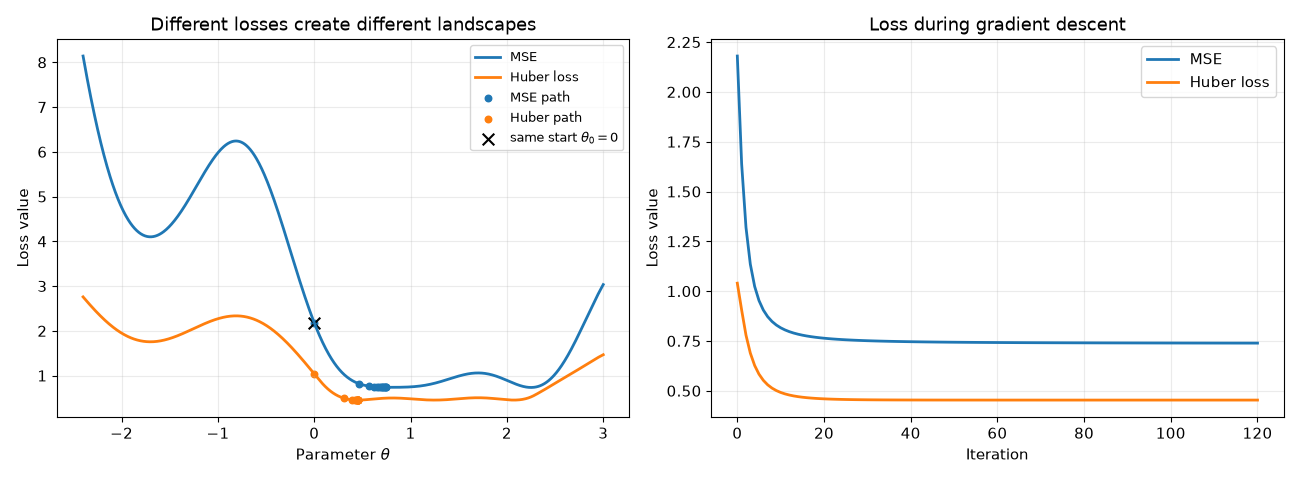

MSE converged to theta = 0.750
Huber loss converged to theta = 0.452


In [3]:
# A nonlinear scalar model makes it possible to inspect the optimization
# landscape directly. The parameter theta is the quantity being learned.
def model(theta):
    return theta + 0.9 * np.sin(2.5 * theta)


def model_derivative(theta):
    return 1.0 + 2.25 * np.cos(2.5 * theta)


# Three regular observations and one large target create an outlier.
targets = np.array([1.0, 1.0, 1.0, 3.8])
huber_delta = 0.8


def mse_loss(theta):
    residuals = model(theta) - targets
    return np.mean(0.5 * residuals**2)


def mse_gradient(theta):
    residuals = model(theta) - targets
    # dL/dtheta = mean(residual) * d(model)/dtheta.
    return np.mean(residuals) * model_derivative(theta)


def huber_loss(theta):
    residuals = model(theta) - targets
    absolute_residuals = np.abs(residuals)
    per_sample_loss = np.where(
        absolute_residuals <= huber_delta,
        0.5 * residuals**2,
        huber_delta * (absolute_residuals - 0.5 * huber_delta),
    )
    return np.mean(per_sample_loss)


def huber_gradient(theta):
    residuals = model(theta) - targets
    absolute_residuals = np.abs(residuals)
    # Huber loss clips the residual contribution once it is large.
    clipped_residuals = np.where(
        absolute_residuals <= huber_delta,
        residuals,
        huber_delta * np.sign(residuals),
    )
    return np.mean(clipped_residuals) * model_derivative(theta)


def gradient_descent(gradient, theta_initial, learning_rate, n_steps):
    path = np.empty(n_steps + 1)
    path[0] = theta_initial
    theta = theta_initial
    for step in range(n_steps):
        theta = theta - learning_rate * gradient(theta)
        path[step + 1] = theta
    return path


theta_grid = np.linspace(-2.4, 3.0, 1000)
mse_landscape = np.array([mse_loss(theta) for theta in theta_grid])
huber_landscape = np.array([huber_loss(theta) for theta in theta_grid])
theta_initial = 0.0
learning_rate = 0.02
n_steps = 120
mse_path = gradient_descent(mse_gradient, theta_initial, learning_rate, n_steps)
huber_path = gradient_descent(huber_gradient, theta_initial, learning_rate, n_steps)
mse_history = np.array([mse_loss(theta) for theta in mse_path])
huber_history = np.array([huber_loss(theta) for theta in huber_path])

fig, (ax_landscape, ax_history) = plt.subplots(1, 2, figsize=(13, 4.8))
ax_landscape.plot(theta_grid, mse_landscape, label="MSE", linewidth=2)
ax_landscape.plot(theta_grid, huber_landscape, label="Huber loss", linewidth=2)
ax_landscape.scatter(mse_path[::10], mse_history[::10], color="tab:blue", s=22, label="MSE path")
ax_landscape.scatter(huber_path[::10], huber_history[::10], color="tab:orange", s=22, label="Huber path")
ax_landscape.scatter([theta_initial], [mse_loss(theta_initial)], color="black", marker="x", s=70, label=r"same start $\theta_0=0$")
ax_landscape.set_title("Different losses create different landscapes")
ax_landscape.set_xlabel(r"Parameter $\theta$")
ax_landscape.set_ylabel("Loss value")
ax_landscape.legend(fontsize=9)
ax_landscape.grid(alpha=0.25)

steps = np.arange(n_steps + 1)
ax_history.plot(steps, mse_history, color="tab:blue", linewidth=2, label="MSE")
ax_history.plot(steps, huber_history, color="tab:orange", linewidth=2, label="Huber loss")
ax_history.set_title("Loss during gradient descent")
ax_history.set_xlabel("Iteration")
ax_history.set_ylabel("Loss value")
ax_history.legend()
ax_history.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f"MSE converged to theta = {mse_path[-1]:.3f}")
print(f"Huber loss converged to theta = {huber_path[-1]:.3f}")

### 4.6 Optional reference: the mathematics of optimizing a neuron

> This subsection is for later consultation. During the live workshop, the main ideas can be summarized as: define the forward model, measure its error with a loss, compute the gradient, and update the parameters.

#### 4.6.1 Forward pass and objective

For one observation, a neuron computes

$$
z_i=w^Tx_i+b,\qquad a_i=\phi(z_i).
$$

The forward pass maps the input $x_i$ to the output $a_i$. Given a differentiable per-observation loss $\ell(a_i,y_i)$, the training objective is

$$
\mathcal{L}(w,b)=\frac{1}{N}\sum_{i=1}^{N}\ell(a_i,y_i).
$$

The optimization problem is to find the parameters $(w,b)$ that minimize this scalar objective.

#### 4.6.2 Applying the chain rule

The loss depends on a weight indirectly: $w_j$ changes $z_i$, which changes $a_i$, which changes the loss. The chain rule gives

$$
\frac{\partial\mathcal{L}}{\partial w_j}=\frac{1}{N}\sum_{i=1}^{N}\frac{\partial\ell(a_i,y_i)}{\partial a_i}\frac{\partial a_i}{\partial z_i}\frac{\partial z_i}{\partial w_j}.
$$

Since $\partial z_i/\partial w_j=x_{ij}$ and $\partial z_i/\partial b=1$, this becomes

$$
\frac{\partial\mathcal{L}}{\partial w_j}=\frac{1}{N}\sum_{i=1}^{N}\frac{\partial\ell}{\partial a_i}\phi'(z_i)x_{ij},\qquad
\frac{\partial\mathcal{L}}{\partial b}=\frac{1}{N}\sum_{i=1}^{N}\frac{\partial\ell}{\partial a_i}\phi'(z_i).
$$

These equations show the three local factors propagated backward: the loss derivative, the activation derivative, and the input or bias derivative.

#### 4.6.3 Example: MSE with an identity neuron

For regression, use $a_i=\phi(z_i)=z_i$ and $\ell_i=\frac{1}{2}(a_i-y_i)^2$. Then

$$
\frac{\partial\ell_i}{\partial a_i}=a_i-y_i,\qquad \phi'(z_i)=1.
$$

Therefore,

$$
\frac{\partial\mathcal{L}}{\partial w}=\frac{1}{N}\sum_{i=1}^{N}(a_i-y_i)x_i,\qquad
\frac{\partial\mathcal{L}}{\partial b}=\frac{1}{N}\sum_{i=1}^{N}(a_i-y_i).
$$

These are exactly the linear-regression gradients. The neuron is not a different mathematical object here; it is the same affine model written in neuron notation.

#### 4.6.4 Example: binary cross-entropy with a sigmoid neuron

For binary classification, let $p_i=\sigma(z_i)$, where $\sigma(z)=1/(1+e^{-z})$, and use

$$
\ell_i=-\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right].
$$

The derivatives are

$$
\frac{\partial\ell_i}{\partial p_i}=-\frac{y_i}{p_i}+\frac{1-y_i}{1-p_i},\qquad
\frac{\partial p_i}{\partial z_i}=p_i(1-p_i).
$$

Multiplying them simplifies the result:

$$
\frac{\partial\ell_i}{\partial z_i}=p_i-y_i.
$$

Consequently, the parameter gradients are

$$
\frac{\partial\mathcal{L}}{\partial w}=\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)x_i,\qquad
\frac{\partial\mathcal{L}}{\partial b}=\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i).
$$

This convenient simplification is one reason sigmoid activation and binary cross-entropy are commonly paired.